In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.3 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/faranbutt/inductive-class-challenge.git

Cloning into 'inductive-class-challenge'...
remote: Enumerating objects: 525, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 525 (delta 29), reused 21 (delta 19), pack-reused 483 (from 1)
Receiving objects: 100% (525/525), 3.17 MiB | 5.25 MiB/s, done.
Resolving deltas: 100% (219/219), done.


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, SAGEConv, GATv2Conv
from torch_geometric.utils import to_undirected
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
import platform
import networkx as nx

In [4]:
START_TIME=time.time()

In [5]:
SEED = 25
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"OS: {platform.system()} {platform.release()}")
print(f"Processor: {platform.processor()}")


Using device: cpu
PyTorch version: 2.10.0+cpu
OS: Linux 6.6.113+
Processor: x86_64


In [7]:
train_edges_df = pd.read_csv("/content/inductive-class-challenge/data/public/edge_list.csv")
train_edges_df

,source,target
0,9526,9548
1,9526,9533
2,9526,9550
3,9526,9557
4,9526,9553
...,...,...
206233,29922,29913
206234,29922,29906
206235,29922,29896
206236,29922,29907


In [8]:
train_df = pd.read_csv('/content/inductive-class-challenge/data/public/train.csv')
train_df

,id,x,y,width,height,label
0,9526,-0.740745,-1.246097,2.216025,3.652787,0
1,9527,0.651995,-0.910300,1.680987,3.115087,0
2,9528,-0.301633,1.170759,2.416664,2.106900,0
3,9529,0.518930,1.294474,1.547228,1.703625,0
4,9530,-1.193164,-0.181266,1.680987,1.703625,0
...,...,...,...,...,...,...
41261,29918,-1.428244,0.689155,-1.061080,-0.783238,0
41262,29919,0.319334,-1.396322,-1.061080,-1.052088,3
41263,29920,0.274979,0.035234,-1.729877,-0.783238,0
41264,29921,0.372560,0.097092,-1.194840,-1.186513,0


In [9]:
test_df = pd.read_csv('/content/inductive-class-challenge/data/public/test_nodes.csv')
test_df

,id,x,y,width,height
0,47532,-1.384657,-0.029077,3.014364,2.313214
1,47533,-0.573018,-1.327630,1.766749,3.138223
2,47534,0.343656,0.362398,2.182621,2.038210
3,47535,1.260330,1.379280,3.152988,0.594444
4,47536,0.042872,-0.749965,1.836061,1.694457
...,...,...,...,...,...
10466,50302,-0.510952,-1.523368,-0.936416,-1.193077
10467,50303,-0.224491,-1.007766,-1.075040,-1.055575
10468,50304,-0.931094,-1.599753,-0.797792,-1.468080
10469,50305,-0.835607,-0.310749,-1.352288,-0.918074


In [10]:
test_edges_df = pd.read_csv('/content/inductive-class-challenge/data/public/test_edges.csv')
test_edges_df

,source,target
0,47532,47545
1,47532,47542
2,47532,47544
3,47532,47541
4,47532,47537
...,...,...
52327,50306,50301
52328,50306,50292
52329,50306,50274
52330,50306,50275


In [11]:
print(f"Train Nodes Len = {len(train_df)}  Length of Train Edges = {len(train_edges_df)}")
print(f"Test Nodes Len = {len(test_df)}  Length of Test Edges = {len(test_edges_df)}")

Train Nodes Len = 41266  Length of Train Edges = 206238
Test Nodes Len = 10471  Length of Test Edges = 52332


In [12]:
class_counts = train_df['label'].value_counts().sort_index()
class_counts

,count
label,
0,16876
1,10818
2,7222
3,6350


In [13]:
print("Stats for Train Nodes Features")
train_df[['x', 'y', 'width', 'height']].describe()

Stats for Train Nodes Features


,x,y,width,height
count,4.126600e+04,4.126600e+04,4.126600e+04,4.126600e+04
mean,-9.986788e-18,-9.022546e-17,-1.336163e-16,-2.259080e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.627840e+00,-1.626078e+00,-2.398674e+00,-2.396337e+00
25%,-8.028416e-01,-8.086769e-01,-7.266818e-01,-7.160250e-01
50%,-5.324614e-02,-5.755173e-02,-2.585239e-01,-2.455375e-01
75%,6.963494e-01,6.979918e-01,6.109121e-01,5.610125e-01
max,5.482228e+00,5.169396e+00,7.566400e+00,8.223237e+00


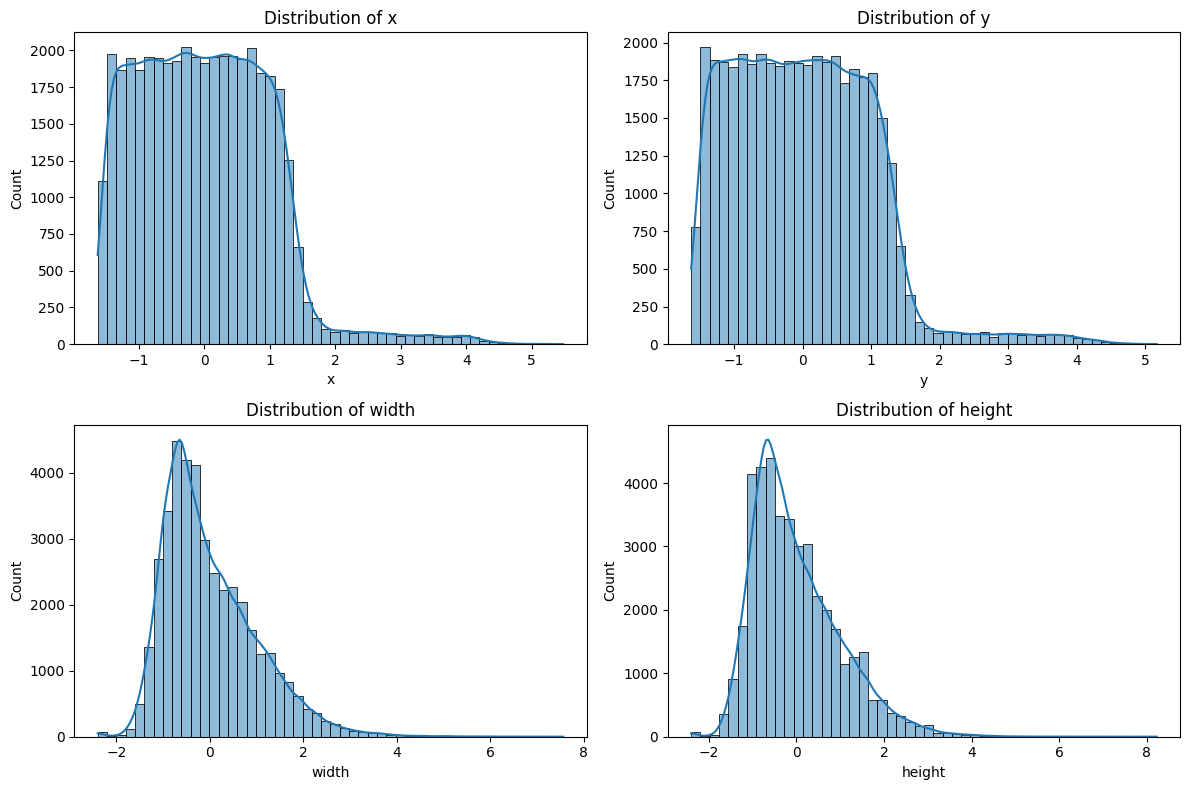

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(['x','y','width','height']):
    ax = axes[i//2, i%2]
    sns.histplot(train_df[col], bins=50, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [15]:
G_train = nx.Graph()
G_train.add_nodes_from(train_df['id'].values)
G_train.add_edges_from(train_edges_df.values.tolist())
print(f"training ggraph=  {G_train.number_of_nodes()} nodes, {G_train.number_of_edges()} edges")
print(f"Graph density =  {nx.density(G_train):.4f}")
print(f"Number of connected components - {nx.number_connected_components(G_train)}")
print(f"avg degree =  {np.mean([d for n,d in G_train.degree()]):.2f}")

training ggraph=  41266 nodes, 124629 edges
Graph density =  0.0001
Number of connected components - 1395
avg degree =  6.04


In [16]:
degrees = [d for d in G_train.degree()]

In [17]:
len(degrees)

41266

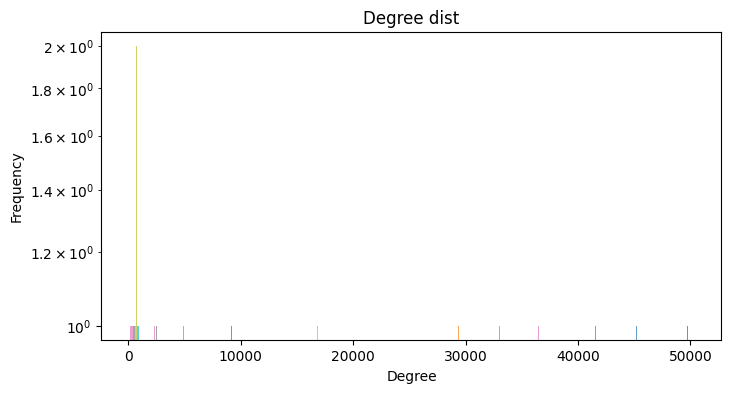

In [18]:
plt.figure(figsize=(8,4))
plt.hist(degrees[:1000],bins=50,alpha=0.7)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree dist")
plt.yscale("log")
plt.show()

In [19]:
scaler = StandardScaler()
train_feat = train_df[['x', 'y', 'width', 'height']].values.astype(np.float32)
scaler.fit(train_feat)

StandardScaler()

In [20]:
def scale(df):
  return scaler.transform(df[['x', 'y', 'width', 'height']].values.astype(np.float32))
def build_graph_data(nodes_df,edges_df,has_labels=True):
  node_ids = nodes_df['id'].values
  id_to_idx ={o_id:i for i ,o_id in enumerate(node_ids)}
  x = torch.tensor(scale(nodes_df),dtype=torch.float)
  src = [id_to_idx[uid] for uid in edges_df['source'].values]
  dst = [id_to_idx[uid] for uid in edges_df['target'].values]
  edge_index = torch.tensor([src,dst], dtype=torch.long)
  edge_index = to_undirected(edge_index)
  if has_labels:
    y = torch.tensor(nodes_df['label'].values, dtype=torch.long)
  else:
    y = None
  return Data(x=x,edge_index=edge_index, y=y)

In [21]:
train_graph = build_graph_data(train_df,train_edges_df,has_labels=True)
test_graph = build_graph_data(test_df,test_edges_df,has_labels=False)

In [22]:
print(f"Train graph nodes = {train_graph.num_nodes} Train Graph Edges = {train_graph.num_edges}")
print(f"Test graph nodes = {test_graph.num_nodes} Test Graph Edges = {test_graph.num_edges}")

Train graph nodes = 41266 Train Graph Edges = 249257
Test graph nodes = 10471 Test Graph Edges = 63181


In [23]:
spliter = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=SEED)
node_idxs = np.arange(train_graph.num_nodes)
labels = train_df['label'].values
train_idx,val_idx = next(spliter.split(node_idxs,labels))

In [24]:
train_idx.shape,val_idx.shape

((33012,), (8254,))

In [25]:
train_mask = torch.zeros(train_graph.num_nodes,dtype=torch.bool)
val_mask = torch.zeros(train_graph.num_nodes,dtype=torch.bool)

In [26]:
train_mask[train_idx] = True
val_mask[val_idx] =True

In [27]:
train_graph.train_mask = train_mask
train_mask.val_mask = val_mask

In [28]:
print(f"Training Nodes = {train_mask.sum()}")
print(f"Val Nodes = {val_mask.sum()}")

Training Nodes = 33012
Val Nodes = 8254


In [29]:
class GCN(nn.Module):
  def __init__(self,in_channels,hidden_channels,out_channels,num_layers,dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(GCNConv(in_channels,hidden_channels))
    self.bns.append(nn.BatchNorm1d(hidden_channels))
    for _ in  range(num_layers-1):
      self.convs.append(GCNConv(hidden_channels,hidden_channels))
      self.bns.append(nn.BatchNorm1d(hidden_channels))
    self.classifier = nn.Linear(hidden_channels, out_channels)
  def forward(self,data):
    x , edge_index = data.x, data.edge_index
    for i, conv in enumerate(self.convs):
      x = conv(x,edge_index)
      x = self.bns[i](x)
      x = F.relu(x)
      x = F.dropout(x,p = self.dropout, training=self.training)
    return self.classifier(x)

In [30]:
class GraphSAGE(nn.Module):
  def __init__(self, in_channels,hidden_channels, out_channels, num_layers, dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(SAGEConv(in_channels, hidden_channels))
    self.bns.append(nn.BatchNorm1d(hidden_channels))
    for _ in range(num_layers - 1):
      self.convs.append(SAGEConv(hidden_channels,hidden_channels))
      self.bns.append(nn.BatchNorm1d(hidden_channels))
    self.classifier = nn.Linear(hidden_channels,out_channels)
  def forward(self,data):
    x, edge_index = data.x , data.edge_index
    for i,conv in enumerate(self.convs):
      x = conv(x,edge_index)
      x = self.bns[i](x)
      x  = F.relu(x)
      x = F.dropout(x,p=self.dropout, training=self.training)
    return self.classifier(x)

In [31]:
class GAT(nn.Module):
  def __init__(self,in_channels, hidden_channels, out_channels, num_layers, no_heads, dropout):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(GATv2Conv(in_channels,hidden_channels,heads=no_heads,concat=True, dropout=dropout))
    self.bns.append(nn.BatchNorm1d(hidden_channels * no_heads))
    for i in range(num_layers-2):
      self.convs.append(GATv2Conv(hidden_channels * no_heads,hidden_channels,heads=no_heads,concat=True, dropout=dropout))
      self.bns.append(nn.BatchNorm1d(hidden_channels * no_heads))
    self.convs.append(GATv2Conv(hidden_channels * no_heads, hidden_channels, heads=1, concat=False))
    self.classifier = nn.Linear(hidden_channels,out_channels)
  def forward(self,data):
    x, edge_index =data.x , data.edge_index
    for i,conv in enumerate(self.convs):
      x = conv(x,edge_index)
      if i < len(self.bns) - 1:
        x = self.bns[i](x)
        x = F.elu(x)
        x = F.dropout(x,p=self.dropout, training=self.training)
    return self.classifier(x)

In [32]:
def train(model,data, optimizer, criterion, train_mask):
  model.train()
  optimizer.zero_grad()
  out = model(data)
  loss = criterion(out[train_mask],data.y[train_mask])
  loss.backward()
  optimizer.step()
  return loss.item()
@torch.no_grad()
def eval(model,data, mask,criterion):
  model.eval()
  out = model(data)
  loss = criterion(out[mask],data.y[mask]).item()
  pred = out.argmax(dim=1)
  y_true = data.y[mask].cpu().numpy()
  y_pred = pred[mask].cpu().numpy()
  f1 = f1_score(y_true,y_pred,average='macro')
  acc=  accuracy_score(y_true, y_pred)
  return f1,acc,loss

In [33]:
class_weights = 1. / class_counts
class_weights = torch.tensor(class_weights,dtype=torch.float).to(device)

In [34]:
def training(model,data,train_mask,val_mask, epochs,lr,weight_decay,patience):
  model = model.to(device)
  data = data.to(device)
  optimizer = torch.optim.Adam(model.parameters(),lr=lr, weight_decay=weight_decay)
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100,eta_min=1e-5)
  criterion = nn.CrossEntropyLoss(weight=class_weights)
  best_val_f1 = 0.0
  best_state =None
  patience_ctr = 0
  history  ={'train_loss':[],'val_loss':[],"val_f1":[],'val_acc':[]}
  start_time=  time.time()
  for epoch in range(1,epochs+1):
    loss = train(model,data,optimizer,criterion,train_mask)
    val_f1, val_acc,val_loss = eval(model,data,val_mask,criterion)
    scheduler.step()
    history['train_loss'].append(loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)
    if epoch % 10 == 0:
      print(f'epoch = {epoch} - Validation Acc= {val_acc} - Val F1 = {val_f1} - val Loss = {val_loss}')
    if val_f1 > best_val_f1:
      best_val_f1 = val_f1
      best_state = copy.deepcopy(model.state_dict())
      patience_ctr = 0
    else:
      patience_ctr += 1
    if patience_ctr >= patience:
      print(f"Stopping Early at {epoch}")
      break
  tot_time = time.time() - start_time
  model.load_state_dict(best_state)
  return model,best_val_f1,history,tot_time

In [35]:
def plotter(hist):
  plt.figure(figsize=(15,5))
  plt.subplot(1,3,1)
  plt.plot(hist['train_loss'],label="Train Loss")
  plt.plot(hist['val_loss'],label='Val Loss')
  plt.title('Loss')
  plt.xlabel("Epoch")
  plt.legend()

  plt.subplot(1,3,2)
  plt.plot(hist['val_acc'],label="Val Acc")
  plt.title("accuracy")
  plt.xlabel("Epoch")
  plt.legend()

  plt.subplot(1,3,3)
  plt.plot(hist['val_f1'],label = "Validation F1")
  plt.title('f1 score')
  plt.xlabel('epoch')
  plt.legend()
  plt.show()

In [36]:
hps= []
run_id = 0

In [37]:
print("GCN")
model_gcn = GCN(in_channels=4,hidden_channels = 64,out_channels = 4,num_layers=2,dropout=0.5)
best_model_gcn,val_f1_gcn, hist_gcn, t_gcn = training(model_gcn,train_graph,train_mask,val_mask, epochs=300,lr=0.01,weight_decay=5e-4,patience=40)
hps.append({'run': run_id+1, 'arch': 'GCN', 'hidden': 64, 'layers': 2, 'val_f1': val_f1_gcn, 'time_sec': t_gcn})
run_id += 1


GCN
epoch = 10 - Validation Acc= 0.6010419190695421 - Val F1 = 0.47136694626204867 - val Loss = 1.1769402027130127
epoch = 20 - Validation Acc= 0.6189726193360795 - Val F1 = 0.47875007489238947 - val Loss = 1.1335104703903198
epoch = 30 - Validation Acc= 0.621153380179307 - Val F1 = 0.48898490610455425 - val Loss = 1.1182326078414917
epoch = 40 - Validation Acc= 0.6167918584928519 - Val F1 = 0.49326798260061006 - val Loss = 1.109047770500183
epoch = 50 - Validation Acc= 0.6161860915919554 - Val F1 = 0.494015340667598 - val Loss = 1.1042628288269043
epoch = 60 - Validation Acc= 0.6147322510298038 - Val F1 = 0.49502896141525243 - val Loss = 1.1006697416305542
epoch = 70 - Validation Acc= 0.6123091834262175 - Val F1 = 0.49606335967003773 - val Loss = 1.0986210107803345
epoch = 80 - Validation Acc= 0.6118245699055004 - Val F1 = 0.49623023788452014 - val Loss = 1.0975072383880615
epoch = 90 - Validation Acc= 0.6121880300460383 - Val F1 = 0.49608292178269675 - val Loss = 1.0965806245803833
e

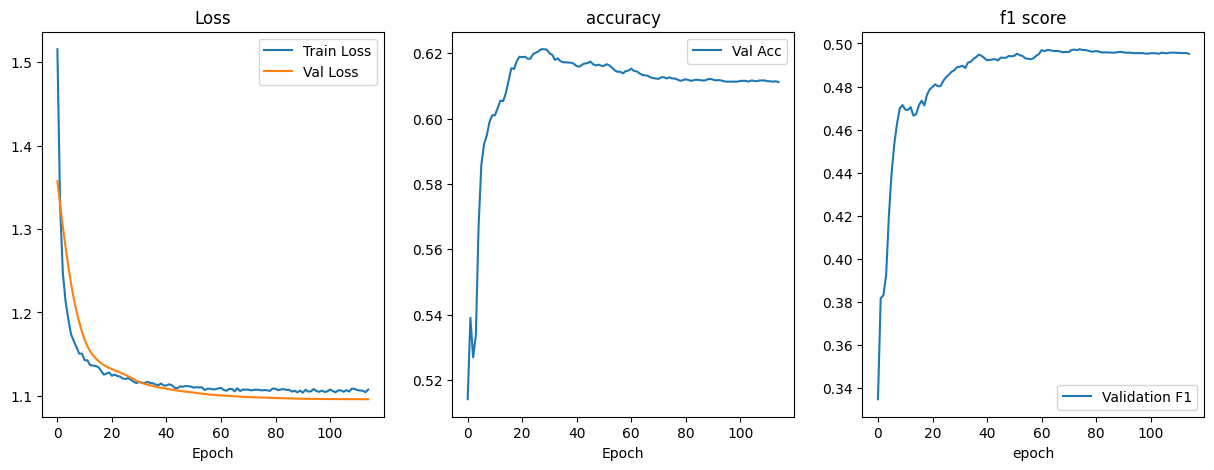

In [38]:
plotter(hist_gcn)

In [39]:
print("GraphSAGE")
model_sage = GraphSAGE(in_channels=4,hidden_channels = 64,out_channels = 4,num_layers=2,dropout=0.5)
best_model_sage,val_f1_sage, hist_sage, t_sage = training(model_sage,train_graph,train_mask,val_mask, epochs=300,lr=0.01,weight_decay=5e-4,patience=40)
hps.append({'run': run_id+1, 'arch': 'GraphSAGE', 'hidden': 64, 'layers': 2, 'val_f1': val_f1_sage, 'time_sec': t_sage})
run_id += 1

GraphSAGE
epoch = 10 - Validation Acc= 0.5977707778047008 - Val F1 = 0.4837651965180419 - val Loss = 1.1208078861236572
epoch = 20 - Validation Acc= 0.6161860915919554 - Val F1 = 0.5371718152889219 - val Loss = 1.0607949495315552
epoch = 30 - Validation Acc= 0.6182456990550036 - Val F1 = 0.5519580221357693 - val Loss = 1.048331618309021
epoch = 40 - Validation Acc= 0.6279379694693482 - Val F1 = 0.5579147337585487 - val Loss = 1.0422978401184082
epoch = 50 - Validation Acc= 0.6343590986188514 - Val F1 = 0.5554725451669652 - val Loss = 1.0341037511825562
epoch = 60 - Validation Acc= 0.6395686939665617 - Val F1 = 0.5577839855005006 - val Loss = 1.0264726877212524
epoch = 70 - Validation Acc= 0.6398110007269203 - Val F1 = 0.5578715954131183 - val Loss = 1.0186690092086792
epoch = 80 - Validation Acc= 0.6392052338260238 - Val F1 = 0.559739574968295 - val Loss = 1.013073444366455
epoch = 90 - Validation Acc= 0.6378725466440514 - Val F1 = 0.5607927276830925 - val Loss = 1.0102510452270508
epo

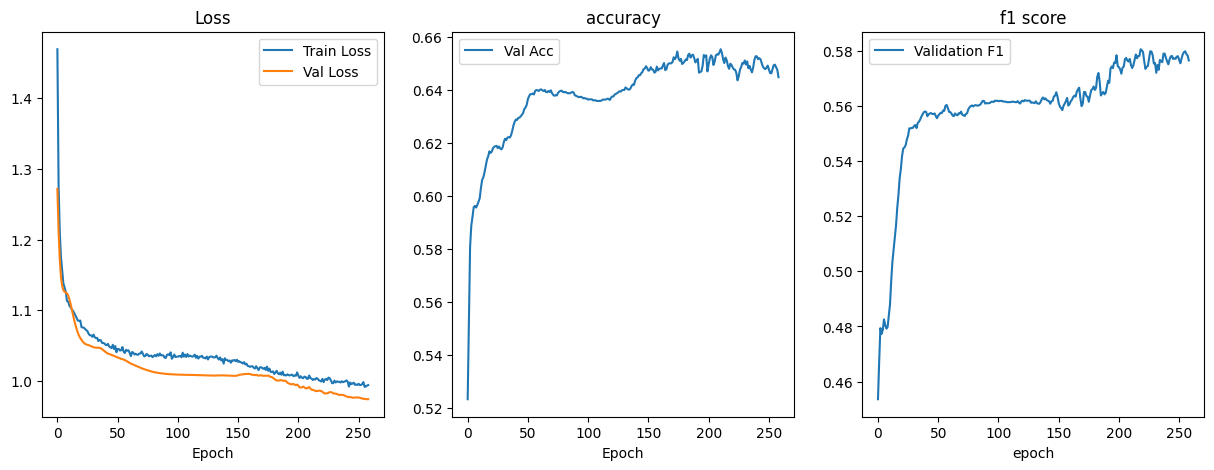

In [40]:
plotter(hist_sage)

In [41]:
print("GAT")
model_gat = GAT(in_channels=4, hidden_channels=64, out_channels=4, no_heads=4, num_layers=2, dropout=0.6)
best_model_gat, best_f1_gat, hist_gat, t_gat = training(model_gat, train_graph, train_mask, val_mask, epochs=500, lr=0.01, weight_decay=5e-4, patience=40)
hps.append({'run': run_id+1, 'arch': 'GAT', 'hidden': 64, 'heads': 4, 'layers': 2, 'val_f1': best_f1_gat, 'time_sec': t_gat})
run_id += 1

GAT
epoch = 10 - Validation Acc= 0.5557305548824812 - Val F1 = 0.41356317587246305 - val Loss = 1.1917734146118164
epoch = 20 - Validation Acc= 0.5700266537436395 - Val F1 = 0.4691627819406499 - val Loss = 1.1444333791732788
epoch = 30 - Validation Acc= 0.5716016476859704 - Val F1 = 0.4769538512969676 - val Loss = 1.1388484239578247
epoch = 40 - Validation Acc= 0.5802035376787013 - Val F1 = 0.4870788086120303 - val Loss = 1.1334197521209717
epoch = 50 - Validation Acc= 0.5822631451417495 - Val F1 = 0.4909446871495125 - val Loss = 1.1281992197036743
epoch = 60 - Validation Acc= 0.5845650593651562 - Val F1 = 0.49572049669022566 - val Loss = 1.1251797676086426
epoch = 70 - Validation Acc= 0.5848073661255149 - Val F1 = 0.49505781859977627 - val Loss = 1.1227540969848633
epoch = 80 - Validation Acc= 0.5837169857039012 - Val F1 = 0.49621048943456064 - val Loss = 1.1216613054275513
epoch = 90 - Validation Acc= 0.5860188999273079 - Val F1 = 0.4972336615934877 - val Loss = 1.1212249994277954
ep

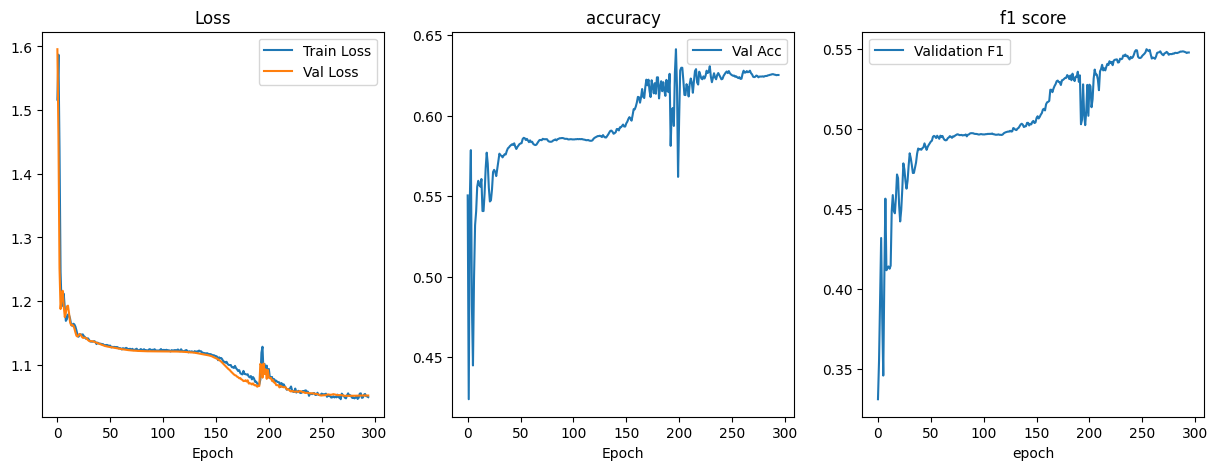

In [42]:
plotter(hist_gat)

In [43]:
print("GraphSAGE v2")
model_sage_v2 = GraphSAGE(in_channels=4,hidden_channels = 128,out_channels = 4,num_layers=2,dropout=0.5)
best_model_sage_v2,val_f1_sage_v2, hist_sage_v2, t_sage_v2 = training(model_sage_v2,train_graph,train_mask,val_mask, epochs=500,lr=0.01,weight_decay=5e-4,patience=40)
hps.append({'run': run_id+1, 'arch': 'GraphSAGE v2', 'hidden': 128, 'layers': 2, 'val_f1': val_f1_sage_v2, 'time_sec': t_sage_v2})
run_id += 1

GraphSAGE v2
epoch = 10 - Validation Acc= 0.61364187060819 - Val F1 = 0.5101528635032387 - val Loss = 1.0799694061279297
epoch = 20 - Validation Acc= 0.612066876665859 - Val F1 = 0.548607941322437 - val Loss = 1.0442427396774292
epoch = 30 - Validation Acc= 0.6223649139811 - Val F1 = 0.5621801301919529 - val Loss = 1.0345474481582642
epoch = 40 - Validation Acc= 0.63811485340441 - Val F1 = 0.5653363350862818 - val Loss = 1.0286040306091309
epoch = 50 - Validation Acc= 0.6445359825539132 - Val F1 = 0.5618458829099074 - val Loss = 1.02251398563385
epoch = 60 - Validation Acc= 0.6491398110007269 - Val F1 = 0.563010292884297 - val Loss = 1.015255331993103
epoch = 70 - Validation Acc= 0.651926338744851 - Val F1 = 0.5703550493806692 - val Loss = 1.0057570934295654
epoch = 80 - Validation Acc= 0.6481705839592925 - Val F1 = 0.5698801363843017 - val Loss = 0.9979783296585083
epoch = 90 - Validation Acc= 0.6448994426944512 - Val F1 = 0.5725895448597683 - val Loss = 0.9939281344413757
epoch = 100

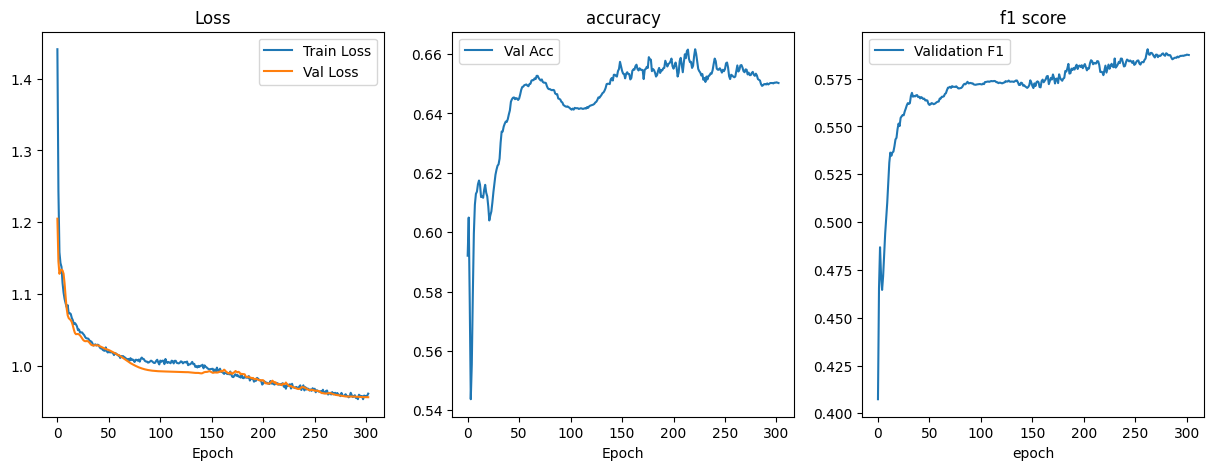

In [44]:
plotter(hist_sage_v2)

In [45]:
print("GraphSAGE v3")
model_sage_v3 = GraphSAGE(in_channels=4,hidden_channels = 128,out_channels = 4,num_layers=3,dropout=0.5)
best_model_sage_v3,val_f1_sage_v3, hist_sage_v3, t_sage_v3 = training(model_sage_v3,train_graph,train_mask,val_mask, epochs=500,lr=0.01,weight_decay=5e-4,patience=40)
hps.append({'run': run_id+1, 'arch': 'GraphSAGE v3', 'hidden': 64, 'layers': 2, 'val_f1': val_f1_sage_v3, 'time_sec': t_sage_v3})
run_id += 1

GraphSAGE v3
epoch = 10 - Validation Acc= 0.5936515628786043 - Val F1 = 0.5028306653916678 - val Loss = 1.1023132801055908
epoch = 20 - Validation Acc= 0.6169130118730313 - Val F1 = 0.5608683115735301 - val Loss = 1.0295840501785278
epoch = 30 - Validation Acc= 0.6350860188999273 - Val F1 = 0.5661115068723703 - val Loss = 1.0202126502990723
epoch = 40 - Validation Acc= 0.6504724981826993 - Val F1 = 0.5702768981306614 - val Loss = 1.018286108970642
epoch = 50 - Validation Acc= 0.653137872546644 - Val F1 = 0.5676445966284466 - val Loss = 1.0096244812011719
epoch = 60 - Validation Acc= 0.6542282529682578 - Val F1 = 0.5655603112450941 - val Loss = 0.9986936450004578
epoch = 70 - Validation Acc= 0.6558032469105888 - Val F1 = 0.5708758034354907 - val Loss = 0.9868020415306091
epoch = 80 - Validation Acc= 0.6526532590259269 - Val F1 = 0.578765885586384 - val Loss = 0.9764010310173035
epoch = 90 - Validation Acc= 0.6496244245214442 - Val F1 = 0.5817019229618199 - val Loss = 0.9703480005264282


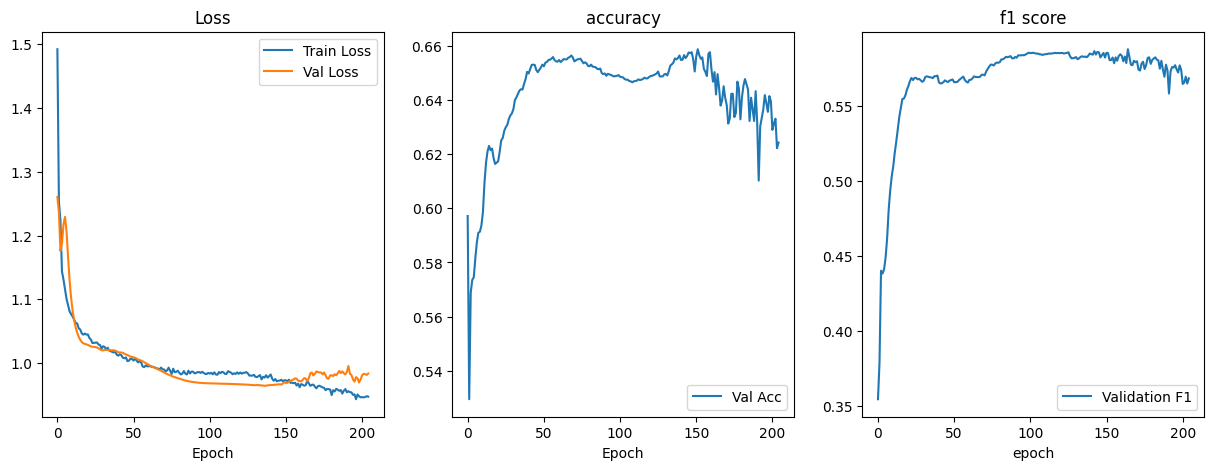

In [46]:
plotter(hist_sage_v3)

In [47]:
pd.DataFrame(hps)

,run,arch,hidden,layers,val_f1,time_sec,heads
0,1,GCN,64,2,0.497335,128.998913,NaN
1,2,GraphSAGE,64,2,0.580489,141.038377,NaN
2,3,GAT,64,2,0.549744,1871.488996,4.0
3,4,GraphSAGE v2,128,2,0.590358,321.138571,NaN
4,5,GraphSAGE v3,64,2,0.587813,376.779214,NaN


Submission


In [48]:
best_model_sage_v3.eval()
test_graph = test_graph.to(device)
with torch.no_grad():
  out = best_model_sage_v3(test_graph)
  pred = out.argmax(dim=1).cpu().numpy()

In [49]:
submission = pd.DataFrame({
    'id': test_df['id'].values,
    'y_pred': pred
})

In [50]:
submission.to_csv('predictions.csv', index=False)

In [51]:
torch.save(best_model_sage_v3.state_dict(),'best_sage_model.pt')

In [52]:
TOTAL_TIME = time.time() - START_TIME
TOTAL_TIME

2916.1015753746033